In [2]:
!pip install wfdb

Found 942 patient files


Processing patients: 100%|██████████| 942/942 [00:02<00:00, 334.89it/s]


Normal patients (without RHD): 426
RHD patients (with mitral murmur): 145
Excluded patients (Abnormal but no murmur): 371
Total processed: 942

Murmur distribution (all patients):
  Present: 172
  Absent: 631
  Unknown: 52

Final class distribution for training:
  Normal: 426
  RHD: 145

Outcome vs Murmur:
murmur    Absent  Present  Unknown
outcome                           
Abnormal     249      145       35
Normal       382       27       17

Label distribution:
label
normal      426
excluded    284
rhd         145
Name: count, dtype: int64


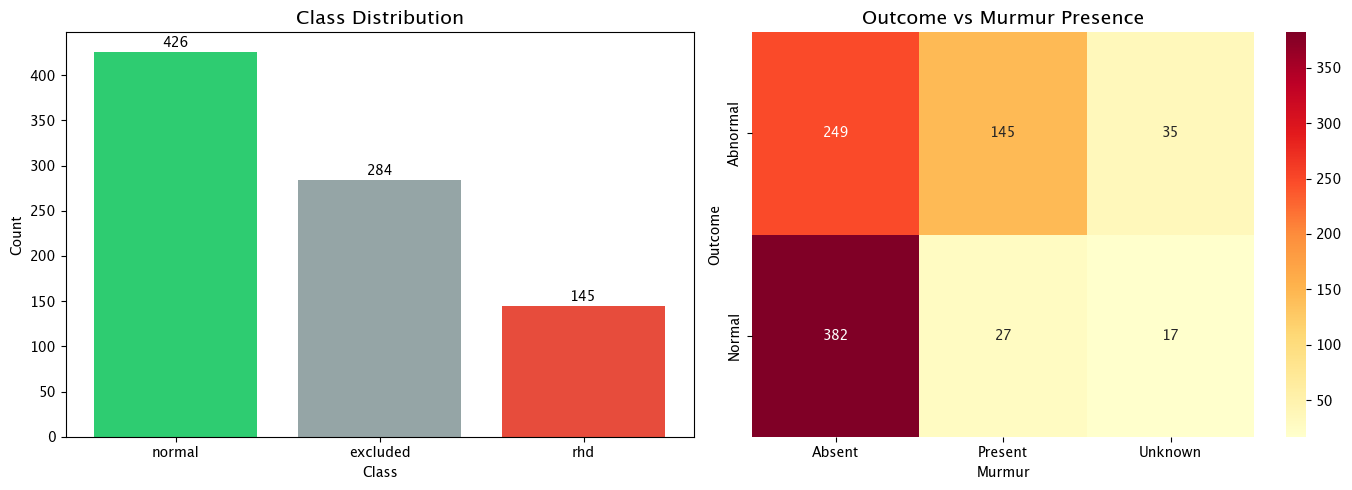


Results saved to: ../data/processed/mitral_valve
  - patient_summary.csv
  - class_distribution.txt
  - data_distribution.png


In [7]:
# preprocess_data.ipynb
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from scipy import signal
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings('ignore')

# Configuration
DATA_PATH = '../data/raw/heart_grades'
OUTPUT_PATH = '../data/processed/mitral_valve'
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'normal'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'rhd'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'excluded'), exist_ok=True)  # Create excluded folder

def parse_patient_file(file_path):
    """Parse the patient .txt file to extract metadata and valve information"""
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    patient_data = {
        'patient_id': None,
        'valves': {},
        'metadata': {}
    }
    
    # First pass - get patient ID and valves
    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        # Parse valve entries (AV, PV, TV, MV)
        if ' ' in line and any(v in line.split()[0] for v in ['AV', 'PV', 'TV', 'MV']):
            parts = line.split()
            if len(parts) >= 4:
                valve = parts[0]
                patient_data['valves'][valve] = {
                    'hea': parts[1],
                    'wav': parts[2],
                    'tsv': parts[3]
                }
        
        # Parse patient ID (first line)
        elif line[0].isdigit():
            parts = line.split()
            if parts:
                patient_data['patient_id'] = parts[0]
    
    # Second pass - parse metadata
    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        # Parse comments with # (metadata)
        if line.startswith('#'):
            key_value = line[1:].strip()
            if ':' in key_value:
                key, value = key_value.split(':', 1)
                patient_data['metadata'][key.strip()] = value.strip()
        # Parse non-comment metadata
        elif ':' in line and not line[0].isdigit():
            parts = line.split(':', 1)
            if len(parts) == 2:
                key = parts[0].strip()
                value = parts[1].strip()
                if key not in patient_data['metadata']:
                    patient_data['metadata'][key] = value
    
    return patient_data

def bandpass_filter(signal_data, lowcut=20, highcut=400, fs=4000, order=4):
    """Apply bandpass filter to remove noise outside the heart sound frequency range"""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    filtered_signal = signal.filtfilt(b, a, signal_data)
    return filtered_signal

def extract_mitral_valve_data(patient_file):
    """Extract mitral valve WAV data for a patient"""
    patient_data = parse_patient_file(patient_file)
    
    if 'MV' not in patient_data['valves']:
        return None, None
    
    valve_data = patient_data['valves']['MV']
    patient_id = patient_data['patient_id']
    
    # Construct paths
    base_dir = os.path.dirname(patient_file)
    wav_file = valve_data['wav']
    
    # Try different path variations
    wav_path = os.path.join(base_dir, wav_file)
    if not os.path.exists(wav_path):
        if not wav_path.endswith('.wav'):
            wav_path = wav_path + '.wav'
        if not os.path.exists(wav_path):
            wav_path = wav_path.replace('.wav', '')
            if not os.path.exists(wav_path):
                return None, None
    
    try:
        # Read WAV file
        signal_data, fs = librosa.load(wav_path, sr=None)
        
        # Apply bandpass filter
        filtered_signal = bandpass_filter(signal_data, fs=fs)
        
        # Get metadata
        outcome = patient_data['metadata'].get('Outcome', 'Normal')
        murmur = patient_data['metadata'].get('Murmur', 'Absent')
        
        return {
            'patient_id': patient_id,
            'signal': filtered_signal,
            'fs': fs,
            'outcome': outcome,
            'murmur': murmur,
            'metadata': patient_data['metadata']
        }, patient_data
    
    except Exception as e:
        print(f"Error processing patient {patient_id}: {e}")
        return None, None

def process_all_patients():
    """Process all patient files and save mitral valve data"""
    all_patients = []
    
    # Find all patient files
    patient_files = []
    for root, dirs, files in os.walk(DATA_PATH):
        for file in files:
            if file.endswith('.txt'):
                try:
                    with open(os.path.join(root, file), 'r') as f:
                        first_line = f.readline().strip()
                        if first_line and first_line.split()[0].isdigit():
                            patient_files.append(os.path.join(root, file))
                except:
                    continue
    
    print(f"Found {len(patient_files)} patient files")
    
    normal_count = 0
    rhd_count = 0
    excluded_count = 0
    
    murmur_present = 0
    murmur_absent = 0
    murmur_unknown = 0
    
    for patient_file in tqdm(patient_files, desc="Processing patients"):
        mitral_data, patient_metadata = extract_mitral_valve_data(patient_file)
        
        if mitral_data is None:
            excluded_count += 1
            continue
        
        # Get outcome and murmur
        outcome = mitral_data['outcome']
        murmur = mitral_data['murmur']
        
        # Track murmur statistics
        if murmur == 'Present':
            murmur_present += 1
        elif murmur == 'Absent':
            murmur_absent += 1
        else:
            murmur_unknown += 1
        
        # LABELING STRATEGY: 
        # RHD = Outcome is "Abnormal" AND Murmur is "Present" (mitral valve murmur)
        # Normal = Outcome is "Normal" 
        # Excluded = Outcome is "Abnormal" but Murmur is "Absent" (not mitral valve related)
        
        patient_id = mitral_data['patient_id']
        signal_data = mitral_data['signal']
        fs = mitral_data['fs']
        
        if outcome == 'Abnormal' and murmur == 'Present':
            # True RHD case with mitral valve murmur
            label = 'rhd'
            rhd_count += 1
            output_dir = os.path.join(OUTPUT_PATH, 'rhd')
            
        elif outcome == 'Normal':
            # Normal patients
            label = 'normal'
            normal_count += 1
            output_dir = os.path.join(OUTPUT_PATH, 'normal')
            
        else:
            # Excluded: Abnormal but no murmur present
            label = 'excluded'
            excluded_count += 1
            output_dir = os.path.join(OUTPUT_PATH, 'excluded')
        
        # Ensure directory exists
        os.makedirs(output_dir, exist_ok=True)
        
        # Save processed WAV file
        output_path = os.path.join(output_dir, f"{patient_id}.wav")
        
        # Handle any potential issues with signal data
        try:
            # Ensure signal is float32 and within valid range
            signal_data = signal_data.astype(np.float32)
            if np.isnan(signal_data).any() or np.isinf(signal_data).any():
                print(f"Warning: Invalid values in signal for patient {patient_id}")
                continue
                
            sf.write(output_path, signal_data, fs)
        except Exception as e:
            print(f"Error saving patient {patient_id}: {e}")
            excluded_count += 1
            continue
        
        # Save metadata
        metadata_path = os.path.join(output_dir, f"{patient_id}_metadata.json")
        with open(metadata_path, 'w') as f:
            json.dump(mitral_data['metadata'], f, indent=2)
        
        all_patients.append({
            'patient_id': patient_id,
            'label': label,
            'outcome': outcome,
            'murmur': murmur
        })
    
    # Save summary
    df = pd.DataFrame(all_patients)
    summary_path = os.path.join(OUTPUT_PATH, 'patient_summary.csv')
    df.to_csv(summary_path, index=False)
    

    print(f"Normal patients (without RHD): {normal_count}")
    print(f"RHD patients (with mitral murmur): {rhd_count}")
    print(f"Excluded patients (Abnormal but no murmur): {excluded_count}")
    print(f"Total processed: {normal_count + rhd_count + excluded_count}")
    
    print(f"\nMurmur distribution (all patients):")
    print(f"  Present: {murmur_present}")
    print(f"  Absent: {murmur_absent}")
    print(f"  Unknown: {murmur_unknown}")
    
    print(f"\nFinal class distribution for training:")
    print(f"  Normal: {normal_count}")
    print(f"  RHD: {rhd_count}")
    
    # Cross-tabulation
    if len(all_patients) > 0:
        print("\nOutcome vs Murmur:")
        cross_tab = pd.crosstab(df['outcome'], df['murmur'])
        print(cross_tab)
        
        print("\nLabel distribution:")
        print(df['label'].value_counts())
    
    return df

def visualize_processed_data(summary_df):
    """Visualize the processed data distribution"""
    if len(summary_df) == 0:
        print("No data to visualize")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Label distribution
    ax1 = axes[0]
    label_counts = summary_df['label'].value_counts()
    colors = ['#2ecc71' if l == 'normal' else '#e74c3c' if l == 'rhd' else '#95a5a6' 
              for l in label_counts.index]
    bars = ax1.bar(label_counts.index, label_counts.values, color=colors)
    ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Class')
    ax1.set_ylabel('Count')
    for i, v in enumerate(label_counts.values):
        ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')
    
    # Outcome vs Murmur heatmap
    ax2 = axes[1]
    cross_tab = pd.crosstab(summary_df['outcome'], summary_df['murmur'])
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', ax=ax2)
    ax2.set_title('Outcome vs Murmur Presence', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Murmur')
    ax2.set_ylabel('Outcome')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'data_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    # Install seaborn if not available
    try:
        import seaborn as sns
    except ImportError:
        import subprocess
        subprocess.check_call(['pip', 'install', 'seaborn'])
        import seaborn as sns
    
    summary_df = process_all_patients()
    
    # Visualize results
    if len(summary_df) > 0:
        visualize_processed_data(summary_df)
        
        # Save class distribution info
        dist = summary_df['label'].value_counts()
        with open(os.path.join(OUTPUT_PATH, 'class_distribution.txt'), 'w') as f:
            f.write("Class Distribution:\n")
            f.write("="*40 + "\n")
            f.write(f"Normal: {dist.get('normal', 0)}\n")
            f.write(f"RHD: {dist.get('rhd', 0)}\n")
            f.write(f"Excluded: {dist.get('excluded', 0)}\n")
            f.write("="*40 + "\n")
            f.write(f"Total: {len(summary_df)}\n")
        
        print(f"\nResults saved to: {OUTPUT_PATH}")
        print(f"  - patient_summary.csv")
        print(f"  - class_distribution.txt")
        print(f"  - data_distribution.png")
    else:
        print("No patients were successfully processed. Please check the data path.")